<a href="https://colab.research.google.com/github/saulo-albuquerque-phys/GWgpu-jax/blob/acceptance_walk_sampler/examples/public_Parameter_Estimation_mlgw_bbh_GW150914_acceptance_walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GWgpu_jax — Acceptance-walk PE on **real GW150914** with **mlgw_bbh_jax** (SEOBNRv5HM, **(2,2) mode only**, **non-uniform priors**, **chirp-mass / mass-ratio sampling**)

This is the **chirp-mass / mass-ratio** variant of
`gwgpu_jax_colab_pe_mlgw_bbh_GW150914_22mode_new_priors.ipynb`. It is identical
except that the binary masses are sampled as the **chirp mass `mc` and mass
ratio `q = m₂/m₁ ≤ 1`** instead of the component masses `m1, m2`. The
geometric parameters keep the **physically-motivated, non-uniform priors**
from `gwgpu_jax.gwgpu_jax_prior_definitions`:

| Parameter     | Prior                 | Density        | Spec |
|---------------|-----------------------|----------------|------|
| `inclination` | isotropic orientation | `p(θ) ∝ sin θ` | `"sin"` (`SinUniform`) |
| `dec`         | isotropic sky         | `p(δ) ∝ cos δ` | `"cos"` (`CosUniform`) |
| `distance`    | uniform in volume     | `p(d) ∝ d²`    | `"volumetric"` (`Volumetric`) |

`mc` and `q` are sampled **uniformly** over their bounds (no `priors` entry).
They are passed via the opt-in `priors=` keyword of
`gwgpu_jax.GWgpu_jaxAcceptanceWalkSampler` (default = unchanged uniform). The
densities are pure JAX / `jit`-traceable and enter the sampler only as its
`logprior_fn`, so the SEOBNRv5HM hot path is unaffected.

It runs the **GWgpu_jax acceptance-walk nested sampler** on **real GW150914**
strain pulled from GWOSC, with the **SEOBNRv5HM** ML surrogate
(`mlgw_bbh_jax`, *model_4*) as the waveform model:

* **Leading (2,2) mode only** — ≈3× faster than the full 7-mode
  evaluation, with essentially no bias for an event like GW150914 that is
  consistent with a near-equal-mass, non-precessing binary. See
  [`gwgpu_jax_colab_pe_mlgw_bbh_GW150914.ipynb`](https://github.com/saulo-albuquerque-phys/GWgpu-jax/blob/main/examples/gwgpu_jax_colab_pe_mlgw_bbh_GW150914.ipynb)
  for the full 7-mode version.
* Aligned spins χ₁, χ₂ ∈ [−0.9, 0.9] (**sampled**, not fixed).
* Mass ratio q = m₂/m₁ ∈ [0.5, 1] (**sampled**); maps to the surrogate's native
  m₁/m₂ ∈ [1, 2], inside its [1, 10] validity range.
* Pure-JAX, JIT/vmap/grad-compatible — drops straight into the GWgpu_jax sampler.

The sampling dimension is **11**: `mc, q, chi_1, chi_2, distance, inclination, ra, dec, psi, phi_c, tc`
(all free). We sample the **chirp mass `mc` and mass ratio `q = m₂/m₁ ≤ 1`**
directly and convert to `(m₁, m₂)` inside the waveform_fn. Because `q ≤ 1`
enforces `m₁ ≥ m₂` by construction, the surrogate is always evaluated in its
`m₁ ≥ m₂` domain, there is **no label-swap degeneracy**, and no heavier-first
relabelling is needed (contrast the `m1, m2` sibling, which samples the
component masses and collapses the two swap modes for display).

The **acceptance-walk sampler** (Prathaban et al. 2025) replaces each
lowest-likelihood live point with a fresh one drawn by the `bilby`/`dynesty`
constrained random walk on the unit hypercube: `n_target` accepted steps per new
point (bilby's `nact`-style control), with `num_delete` points replaced per
iteration (batched on GPU). It is the LIGO/Virgo-standard nested-sampling kernel,
GW-validated within `blackjax-ns`; the likelihood, waveform, and priors are
unchanged from the NSS run.

**Runtime → Change runtime type → T4 GPU** before running. The waveform call
is heavier than ripplegw (a small Keras MLP is evaluated for each particle), so
expect a longer JIT compile than ripplegw, though the single (2,2) mode
keeps the steady-state iteration close to the ripplegw notebook.

## 1. Install GWgpu_jax

[GWgpu-jax](https://github.com/saulo-albuquerque-phys/GWgpu-jax) is a **public**
repository — no GitHub token or authentication is needed. The cell below installs
it straight from GitHub.

Colab GPU runtimes already ship a CUDA-enabled JAX, so the `gpu` extra is not
required; the cell re-pins JAX to the 0.4.x line that Colab's CUDA plugin
supports. Requires **Python 3.11**, which is what Colab provides.


In [ ]:
import importlib.util, os

RUNNING_ON_COLAB  = importlib.util.find_spec("google.colab") is not None
ALREADY_INSTALLED = importlib.util.find_spec("gwgpu_jax") is not None

if RUNNING_ON_COLAB and not ALREADY_INSTALLED:
    # Pin JAX to the 0.4.x line Colab's CUDA plugin still supports.
    !pip uninstall -y -q jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt 2>/dev/null
    !pip install -q "jax[cuda12]==0.4.31" "jaxlib==0.4.31"

    # Public repo - no token, no authentication. Installs from the default branch.
    !pip install -q "gwgpu_jax[data,mlgw] @ git+https://github.com/saulo-albuquerque-phys/GWgpu-jax.git"

    print("Installed. If JAX was re-pinned: Runtime -> Restart session, then re-run from here.")
else:
    print("gwgpu_jax already importable - skipping install.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.2/84.2 MB 27.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
flax 0.10.6 requires jax>=0.5.1, but you have jax 0.4.31 which is incompatible.
orbax-checkpoint 0.11.16 requires jax>=0.5.0, but you have jax 0.4.31 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 9.2 MB/s 

### 1b. Pull the vendored `mlgw_bbh_jax` sub-repo (Colab bandaid)

IMPORTANT: RESTART THE SECTION BEFORE RUNNING HERE. GO IN EXEC ENVIRONMENTS IN THE TOP BAR ON TOP OF THE NOTEBOOK, CLICK THERE, AND THEN CLICK RESTART SECTION, AND THEN YOU CAN START FROM THE CELL BELLOW AND GO DOWNWARDS!

`mlgw_bbh_jax` is shipped as a *vendored* sub-repo at
`<gwgpu_jax-install>/mlgw_jax/mlgw_bbh_jax/`. It is currently **not committed to
the main branch** of the GWgpu_jax repository that Colab clones from, so the
wheel built on Colab is missing it. The cell below clones it on the fly from
the **`gwgpu_jax_compatible`** branch of `adrianomascioli/MLGW-JAX`, which
already contains the inference-compatibility fixes — so, unlike the original
notebook, **no on-the-fly source patch is applied**.

Skip this cell if you're running locally against a working tree that
already has `mlgw_bbh_jax/` populated.

In [ ]:
# ── Vendored-subrepo bandaid for `gwgpu_jax[mlgw]` on Colab ────────────
# The `mlgw_bbh_jax` Python package is a vendored sub-repo that lives at
#     <gwgpu_jax-install>/mlgw_jax/mlgw_bbh_jax/
# but it's not committed to the GWgpu_jax repo Colab clones from, so the
# wheel built on Colab is missing it. We clone it from the upstream
# `gwgpu_jax_compatible` branch of adrianomascioli/MLGW-JAX, which already
# bakes in the inference-compatibility fixes (Keras 2/3 model-load compat,
# optional keras_tuner / GW_helper imports, JAX-traceable Wigner-d), so
# — unlike the original notebook — NO on-the-fly patch is applied.
#
# Once `mlgw_bbh_jax` is properly committed to the GWgpu_jax repo (or pinned
# as a submodule), this whole cell can be deleted.
import subprocess, sys, shutil
from pathlib import Path

# FIX: Downgrade cryptography to fix pyOpenSSL incompatibility (module 'lib' has no attribute 'GEN_EMAIL')
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "cryptography<44", "pyopenssl"],
    check=True,
)

# 1. Install training-only deps the upstream sub-repo may import. On the
#    gwgpu_jax_compatible branch these imports are already guarded, so this
#    is belt-and-braces and can be dropped if you like.
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "keras-tuner"],
    check=True,
)

# 2. Clone the vendored sub-repo (gwgpu_jax_compatible branch) into the
#    gwgpu_jax install path.
import gwgpu_jax
_GW    = Path(gwgpu_jax.__file__).resolve().parent
_DEST  = _GW / "mlgw_jax" / "mlgw_bbh_jax"
_READY = _DEST / ".gwgpu_jax_compatible_ready"

if _READY.exists():
    print(f"✓ mlgw_bbh_jax (gwgpu_jax_compatible) already present at {_DEST}")
else:
    if _DEST.exists():
        shutil.rmtree(_DEST)
    print(f"Cloning mlgw_bbh_jax (gwgpu_jax_compatible) into {_DEST} (~1 GB, ~1–2 min on Colab)…")
    subprocess.run([
        "git", "clone", "--depth", "1",
        "--branch", "gwgpu_jax_compatible",
        "https://github.com/adrianomascioli/MLGW-JAX.git",
        str(_DEST),
    ], check=True)
    _READY.touch()
    print(f"✓ mlgw_bbh_jax cloned (gwgpu_jax_compatible) at {_DEST}")

# 3. Verify the wrapper can now import the vendored Python package.
from gwgpu_jax.mlgw_jax.mlgw_bbh_jax_waveform_generator import MLGWBBHGenerator  # noqa: F401
print("✓ MLGWBBHGenerator importable")

Cloning mlgw_bbh_jax (gwgpu_jax_compatible) into /usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax (~1 GB, ~1–2 min on Colab)…
✓ mlgw_bbh_jax cloned (gwgpu_jax_compatible) at /usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax
✓ MLGWBBHGenerator importable


In [ ]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # silence TF startup spam

import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Enable double precision — important for likelihood accuracy.
jax.config.update("jax_enable_x64", True)

import gwgpu_jax
print("gwgpu_jax version :", gwgpu_jax.__version__)
print("JAX devices   :", jax.devices())

gwgpu_jax version : 0.1.0
JAX devices   : [CudaDevice(id=0)]


## 2. Build the detector network (GW150914 standard window)

GW150914 was observed by H1 and L1. We use the LVC-standard analysis
window for this event: **4 s @ 4 kHz** in the **20–1024 Hz** band. The
`TimeFrequencyGrid` is shared across all detectors in the network.

In [ ]:
DURATION       = 4.0
SAMPLING_RATE  = 4096.0
F_MIN, F_MAX   = 20.0, 1024.0

grid = gwgpu_jax.TimeFrequencyGrid(
    duration=DURATION, sampling_rate=SAMPLING_RATE,
    f_min=F_MIN, f_max=F_MAX,
)
network = gwgpu_jax.Network.from_names(["H1", "L1"], grid)
print(grid)
print(network)

TimeFrequencyGrid(duration=4.0s, sampling_rate=4096.0Hz, initial_time=0.0s, N=16384, df=0.250000Hz, f_min=20.0Hz, f_max=1024.0Hz, n_band_bins=4017)
Network(['H1', 'L1'])


## 3. Fetch real GW150914 strain from GWOSC

`gwgpu_jax.compat.attach_event_to_network` does three things in one shot:

1. Downloads H1 and L1 strain around the GW150914 trigger via
   `gwpy.TimeSeries.fetch_open_data` (needs an internet connection).
2. Estimates each IFO's PSD from an **adjacent off-source** segment (32 s
   ending 8 s before the trigger) with Welch's method.
3. Crops + resamples the on-source segment so the **merger sits at
   0.875 × duration = 3.5 s** into the segment, then attaches strain
   and PSD to every IFO in the network.

The 3.5 s offset is the convention the GWgpu_jax `tc` parameter must match
(see cell 11).

In [ ]:
import time

t0 = time.perf_counter()
gwgpu_jax.compat.attach_event_to_network(
    network, "GW150914",
    estimate_psd          = True,
    psd_segment_duration  = 32.0,
    psd_offset            = 8.0,
    verbose               = False,
)
print(f"GW150914 strain + PSDs attached in {time.perf_counter()-t0:.1f} s")
print(f"  populated detectors : {[ifo.name for ifo in network.interferometers]}")

GW150914 strain + PSDs attached in 35.5 s
  populated detectors : ['H1', 'L1']


## 4. Build a `(params, freqs) -> (h₊, hₓ)` waveform_fn from mlgw_bbh_jax

`MLGWBBHGenerator` is a **time-domain** waveform model: it returns h₊(t),
hₓ(t) on a user-supplied time grid with the merger (waveform peak) placed
at **t = 0**. The GWgpu_jax sampler expects an **FD** waveform
`(params, freqs) -> (ĥ₊, ĥₓ)`, so the shim below converts TD → FD with the
GWgpu_jax convention `ĥ(f_k) = rfft(h)[k] × dt`. Two details (both from the
upstream `mlgw.GW_FD_generator`) are **essential for real-data PE** and are
invisible to inject↔recover, so they're easy to miss:

* **The time grid must cross zero.** mlgw_bbh zeros the amplitude outside its
  native range, so a grid that stops at `-dt` drops the peak *and the whole
  ringdown*, leaving a distorted template that rails `tc` and the masses at
  the prior edges. We evaluate on `[final_time − duration, final_time − dt]`
  with `final_time = 0.01 s`, so the peak and ringdown are sampled.
* **Taper before the rFFT.** An asymmetric Tukey window (long `alpha_left`
  on the inspiral turn-on, tiny `alpha_right` on the ringdown edge)
  suppresses the spectral leakage from the hard segment boundaries.

Two notes about the parameter mapping:

* We sample the **chirp mass `mc` and mass ratio `q = m₂/m₁ ≤ 1`** and
  convert to component masses inside the waveform_fn via
  `m₁ = mc·(1+q)^{1/5}·q^{-3/5}`, `m₂ = q·m₁`.
  `mlgw_bbh_jax` requires **m₁ ≥ m₂**, which `q ≤ 1` guarantees by
  construction — so no internal mass/spin swap and no label-swap
  degeneracy. The posterior is directly `(mc, q, χ₁, χ₂)` with `χ₁` the
  heavier-body spin.
* `phi_c` in our particle dict feeds the surrogate's reference orbital
  phase `phi_0` and the projection-layer phase.

The model loads (TensorFlow → tf2jax) on first construction; the JIT path is
cached internally so repeated calls with the same time grid don't recompile.

In [ ]:
from gwgpu_jax.mlgw_jax.mlgw_bbh_jax_waveform_generator import MLGWBBHGenerator

# ── TD→FD recipe (self-contained so it works against any installed gwgpu_jax) ─────
# Two corrections vs the naive `rfft(hp) * dt`, both lifted from the upstream
# `mlgw.GW_FD_generator` and both essential for *real-data* PE (they cancel in
# inject↔recover, so synthetic tests don't catch them):
#
#   1. The mlgw time grid must CROSS ZERO. mlgw_bbh puts the waveform peak at
#      t = 0 and zeros the amplitude outside its native range. A grid that
#      stops at -dt (the old `time_domain_array_mlgw`) drops the peak + the
#      whole ringdown -> distorted template that rails tc and the masses.
#      We rebuild it as [final_time - duration, final_time - dt] with a small
#      positive `final_time` so the peak + ringdown are sampled.
#   2. An asymmetric Tukey taper applied in the time domain before the rFFT,
#      to kill spectral leakage from the inspiral turn-on (long alpha_left)
#      and the truncated ringdown edge (tiny alpha_right).

MLGW_FINAL_TIME = 0.01   # s of post-merger time kept at the tail (peak+ringdown)
TUKEY_ALPHA_LEFT, TUKEY_ALPHA_RIGHT = 0.2, 0.001

def _tukey_asymmetric(n, alpha_left, alpha_right):
    """Asymmetric Tukey window (JAX-traceable). Matches GW_FD_generator."""
    x = jnp.linspace(0.0, 1.0, n)
    w = jnp.ones_like(x)
    left  = 0.5 * (1.0 + jnp.cos(2.0 * jnp.pi * (x / alpha_left - 0.5)))
    right = 0.5 * (1.0 + jnp.cos(2.0 * jnp.pi * ((x - 1.0) / alpha_right + 0.5)))
    w = jnp.where(x < alpha_left  / 2.0, left,  w)
    w = jnp.where(x > 1.0 - alpha_right / 2.0, right, w)
    return w

def build_mlgw_bbh_waveform_fn(grid, modes=None,
                               final_time=MLGW_FINAL_TIME,
                               alpha_left=TUKEY_ALPHA_LEFT,
                               alpha_right=TUKEY_ALPHA_RIGHT):
    """Return a JAX-traceable ``(params, freqs) -> (hp, hc)`` callable.

    The TD surrogate is evaluated on a zero-crossing grid and converted to the
    GWgpu_jax FD convention ĥ(f_k) = rfft(h)[k]·dt after an asymmetric Tukey taper.

    Either mass ordering is fine: mlgw_bbh swaps m1 <-> m2 (with their spins)
    internally, so the surrogate is always evaluated in its q_mlgw = m1/m2 in
    [1, 10] domain.

    NOTE on ``model=4``: the wrapper default is the string ``"model_4"``, but
    ``mlgw.GW_generator`` only resolves the bundled TD_models/model_<N> path
    for an **int**; passing ``model=4`` finds the SEOBNRv5HM weights.
    """
    bbh    = MLGWBBHGenerator(model=4)
    dt     = grid.dt
    N      = grid.n_samples
    # Zero-crossing grid: [final_time - duration, final_time - dt], step dt.
    # (Equivalent to grid.time_domain_array_mlgw once the package carries the
    #  mlgw_final_time fix; rebuilt here so the notebook is version-independent.)
    t_grid = jnp.arange(N) * dt - grid.duration + final_time
    window = _tukey_asymmetric(N, alpha_left, alpha_right)
    gen_wf = bbh.generate  # = self._gen.get_WF (pure JAX, traceable)

    def waveform_fn(params, freqs):
        # Sample the chirp mass `mc` and mass ratio `q = m2/m1 in (0, 1]`
        # directly, then convert to component masses. q <= 1 enforces m1 >= m2
        # by construction, so the surrogate is always called in its m1 >= m2
        # domain and there is NO label-swap degeneracy (no heavier-first
        # relabelling needed downstream).
        mc     = params["mc"]
        q      = params["q"]                       # q = m2/m1 in (0, 1]
        m1     = mc * (1.0 + q) ** (1.0 / 5.0) / q ** (3.0 / 5.0)
        m2     = q * m1
        chi_1  = params["chi_1"]
        chi_2  = params["chi_2"]

        # theta = [m1, m2, s1z, s2z, d_L, inclination, phi_0]
        theta = jnp.stack([
            m1, m2,
            chi_1, chi_2,
            params["distance"],
            params["inclination"],
            params["phi_c"],
        ])
        hp_td, hc_td = gen_wf(theta, t_grid, modes=modes)
        # Tukey taper in TD, then rFFT * dt (GWgpu_jax FD convention).
        hp_fd = jnp.fft.rfft(hp_td * window) * dt
        hc_fd = jnp.fft.rfft(hc_td * window) * dt
        return hp_fd, -hc_fd

    return waveform_fn

t0 = time.perf_counter()
waveform_fn = build_mlgw_bbh_waveform_fn(grid, modes=(2, 2))
print(f"mlgw_bbh_jax (SEOBNRv5HM, model_4, (2,2) mode) loaded in {time.perf_counter()-t0:.1f} s")


/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/21/amp_weights_0123.keras
ListWrapper(['1-mc_chieff'])
 
 features_spec:  {'base': [0, 3], 'poly': []}
/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/21/ph_weights_01_residual.keras
ListWrapper(['2-mc_eta_logq_chieff'])
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/21/ph_weights_01.keras
ListWrapper(['3-mc_eta_logq_chieff'])
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)

/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/GW_generator.py:173: UserWarning: Folder .DS_Store: name not recognized as a valid mode - skipping its content
  warnings.warn('Folder {}: name not recognized as a valid mode - skipping its content'.format(name))


ListWrapper(['2-mc_eta_logq_chieff'])
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/32/ph_weights_01.keras
ListWrapper(['3-mc_eta_logq_chieff'])
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/32/ph_weights_2345.keras
ListWrapper(['1-mc_eta_logq_chieff'])
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/usr/local/lib/python3.11/dist-packages/gwgpu_jax/mlgw_jax/mlgw_bbh_jax/mlgw/TD_models/model_4/22/amp_weights_

## 5. Set up the acceptance-walk nested sampler (with non-uniform priors)

11-dimensional prior. The new piece vs. the uniform mlgw_bbh notebook is the
**`priors=`** argument: `PARAM_BOUNDS` still sets each parameter's support
`(a, b)`, while `priors` overrides the *shape* of the geometric ones —
`"inclination": "sin"` (`p(θ) ∝ sin θ`), `"dec": "cos"` (`p(δ) ∝ cos δ`),
`"distance": "volumetric"` (`p(d) ∝ d²`). Every other parameter stays uniform.

Other differences vs. the ripplegw two-phase notebook:

* **Spins are sampled**, not fixed: `chi_1, chi_2 ∈ [-0.9, 0.9]` (the
  full validity range of `mlgw_bbh_jax`).
* The `tc` prior is centred at **3.5 s = 0.875 × duration**, matching
  where `attach_event_to_network` places the merger in the cropped
  segment (a half-second window comfortably covers the trigger
  uncertainty).
* The mass prior is **uniform in `mc` and `q = m₂/m₁ ≤ 1`**, GW150914-centred;
  the waveform_fn converts `(mc, q) → (m₁, m₂)`, and `q ≤ 1` makes `m₁ ≥ m₂`
  automatic (no internal swap, no label-swap modes).

Published-median values from GWTC-1 are kept as plot overlays only; they
are *not* used as priors or as a truth target.

In [ ]:
TC_CENTER = 0.875 * grid.duration   # 3.5 s for the 4-s GW150914 segment

# Sample the chirp mass `mc` and mass ratio `q = m2/m1 in (0, 1]` directly
# (instead of the component masses). The waveform_fn converts (mc, q) ->
# (m1, m2); because q <= 1 enforces m1 >= m2, there is no label-swap degeneracy
# and no heavier-first relabelling is needed. Bounds are GW150914-centred
# (mc ~ 28.7, q ~ 0.86); q <= 1 maps to the surrogate's q_mlgw = m1/m2 = 1/q in
# [1, 2], well inside its [1, 10] validity range. The tc prior is +-0.1 s around
# the merger.
PARAM_BOUNDS = {
    "mc":          (26.0, 32.0),
    "q":           (0.6,  1.0),
    "chi_1":       (-0.4, 0.4),
    "chi_2":       (-0.4, 0.4),
    "distance":    (150.0, 700.0),
    "inclination": (0,  float(jnp.pi)),
    "ra":          (0.0,  2.0 * float(jnp.pi)),
    "dec":         (-float(jnp.pi) / 2, float(jnp.pi) / 2),
    "psi":         (0.0,  float(jnp.pi)),
    "phi_c":       (0.0,  2.0 * float(jnp.pi)),
    "tc":          (TC_CENTER - 0.1, TC_CENTER + 0.1),
}
FIXED_PARAMS = {}

# ── NEW: non-uniform priors on the geometric parameters ─────────────────
# String aliases resolved by gwgpu_jax.gwgpu_jax_prior_definitions over the
# matching PARAM_BOUNDS support. Equivalent explicit form:
#   from gwgpu_jax import SinUniform, CosUniform, Volumetric
#   PRIORS = {
#       "inclination": SinUniform(0.0, float(jnp.pi)),
#       "dec":         CosUniform(-float(jnp.pi)/2, float(jnp.pi)/2),
#       "distance":    Volumetric(100.0, 800.0),
#   }
PRIORS = {
    "inclination": "sin",          # p(θ) ∝ sin θ   (isotropic orientation)
    "dec":         "cos",          # p(δ) ∝ cos δ   (isotropic sky)
    "distance":    "volumetric",   # p(d) ∝ d²      (uniform in volume)
}

# Published-median reference (GWTC-1) for the corner-plot overlay only.
PUBLISHED_MEDIAN = dict(
    mc=28.71, q=0.860,  # GW150914 GWTC-1 detector-frame (mc, q=m2/m1) from m1=35.6, m2=30.6
    chi_1=0.0, chi_2=0.0,
    distance=440.0, inclination=2.5,
    ra=2.21, dec=-1.25, psi=0.0,
    phi_c=0.0,
    tc=TC_CENTER,
)

# Acceptance-walk sampler (Prathaban et al. 2025) — same likelihood/priors as NSS,
# only the sampling kernel differs (bilby/dynesty acceptance-walk, GW-validated).
sampler = gwgpu_jax.GWgpu_jaxAcceptanceWalkSampler(
    network       = network,
    waveform_fn   = waveform_fn,
    param_bounds  = PARAM_BOUNDS,
    fixed_params  = FIXED_PARAMS,
    priors        = PRIORS,                        # same non-uniform priors as NSS
    gmst          = None,                          # auto-uses network.gmst
    periodic_params = ("phi_c", "ra"),             # wrap these angles on the unit cube
)
print(f"sampling dimension : {len(sampler.param_bounds)}")
print(f"free parameters    : {list(sampler.param_bounds)}")
print("priors             :", {k: type(v).__name__ for k, v in sampler._prior_specs.items()})
print(f"fixed parameters   : {FIXED_PARAMS}")

sampling dimension : 11
free parameters    : ['mc', 'q', 'chi_1', 'chi_2', 'distance', 'inclination', 'ra', 'dec', 'psi', 'phi_c', 'tc']
priors             : {'mc': 'Uniform', 'q': 'Uniform', 'chi_1': 'Uniform', 'chi_2': 'Uniform', 'distance': 'Volumetric', 'inclination': 'SinUniform', 'ra': 'Uniform', 'dec': 'CosUniform', 'psi': 'Uniform', 'phi_c': 'Uniform', 'tc': 'Uniform'}
fixed parameters   : {}


## 6. Run the acceptance-walk sampler

Same tuning knobs as the ripplegw two-phase notebook:

- `phase1_num_delete` between `num_live // 100` (very safe) and
  `num_live // 20` (faster, slight bias). We use `num_live // 20 = 25`.
- `phase1_delta_logz_threshold = -1.0` switches to phase 2 when the
  live points still hold ≈ 37 % of total `Z`.
- `phase2_num_delete = 1` is the classical Skilling choice (unbiased).
- `log_dlogz_target = -3.0` is phase-2's final convergence tolerance.
- `num_inner_steps = 50` (≈ 5·d for d = 10).

**Compilation warning.** Each phase compiles a separate XLA program
(`num_delete` is baked into the program); on top of that, the
SEOBNRv5HM tf2jax kernel itself is non-trivial, so the first compile in
particular can take **2–3 minutes** even on a T4. Steady-state
iterations are still fast (the model is a small MLP); plan for a total
wall-clock of ≈10–20 minutes at the settings below.

In [ ]:
import os, sys, subprocess
KDIR = "/content/blackjax_ns_gw"
if not os.path.isdir(f"{KDIR}/src/custom_kernels"):
    subprocess.run(["git","clone","--no-checkout","--depth","1","--filter=blob:none",
                    "https://github.com/mrosep/blackjax_ns_gw.git", KDIR], check=True)
    subprocess.run(["git","-C",KDIR,"sparse-checkout","set","src/custom_kernels"], check=True)
    subprocess.run(["git","-C",KDIR,"checkout"], check=True)
sys.path.insert(0, f"{KDIR}/src")
os.environ["GWJAX_ACCEPTANCE_WALK_SRC"] = f"{KDIR}/src"
import custom_kernels
print("✓ acceptance-walk kernel ready:", custom_kernels.__file__)

✓ acceptance-walk kernel ready: /content/blackjax_ns_gw/src/custom_kernels/__init__.py


In [ ]:
NUM_LIVE   = 2000
N_TARGET   = 100      # accepted MCMC walk steps per new point (bilby nact-style); raise for tighter posteriors
MAX_MCMC   = 1200    # hard cap on proposals per new point
NUM_DELETE = 100      # live points replaced per NS step (batched on GPU; 1 = lowest bias)

t0 = time.perf_counter()
result = sampler.run(
    rng_key               = jax.random.PRNGKey(0),
    num_live              = NUM_LIVE,
    n_target              = N_TARGET,
    max_mcmc              = MAX_MCMC,
    num_delete            = NUM_DELETE,
    max_iterations        = 10000,
    log_dlogz_target      = -3,
    num_posterior_samples = 10000,
    verbose               = True,
)
elapsed = time.perf_counter() - t0

print(f"\ntotal wall-clock   = {elapsed:.1f} s")
print(f"  iterations       = {result.n_iterations}")
print(f"  log Z            = {result.logZ:+.3f} ± {result.logZ_err:.3f}")
print(f"  ESS              = {result.ess:.1f}")

JIT-compiling acceptance-walk NS kernel… (one-off; first step is slow)
  → compile + first step in 9.7 s.
iter     0  logZ=-104541.629  logZ_live=-103806.930  Δ=+734.699
iter   100  logZ=-103953.591  logZ_live=-103680.010  Δ=+273.581
iter   200  logZ=-103771.812  logZ_live=-103677.210  Δ=+94.601
iter   300  logZ=-103688.334  logZ_live=-103669.673  Δ=+18.661
iter   400  logZ=-103671.839  logZ_live=-103669.759  Δ=+2.079
iter   500  logZ=-103669.696  logZ_live=-103672.138  Δ=-2.442

total wall-clock   = 741.6 s
  iterations       = 515
  log Z            = -103669.615 ± 0.107
  ESS              = 12732.1


In [ ]:
minutes = elapsed / 60
print(f"Total time for PE: {minutes:.2f} minutes")

Total time for PE: 12.36 minutes


## 7. Posterior summary

The "reference" column is the GWTC-1 published median (visual aid only,
not a truth target). If you see ⚠ collapsed columns / very low ESS
below, the NS budget was too small for the 10-D problem — bump
`NUM_LIVE` to 800–1000 or `NUM_INNER_STEPS` to 60 and re-run cells 11
→ 13.

In [ ]:
# No heavier-first relabelling needed: we sampled q = m1/m2 >= 1 directly, so
# m1 >= m2 holds by construction and there is no (m1,chi_1) <-> (m2,chi_2)
# label-swap degeneracy to collapse. chi_1 is already the heavier-body spin.

print(f"  {'param':12s}  {'median':>10s}  {'-1σ':>8s}  {'+1σ':>8s}  reference")
degenerate = []
for name in sampler.param_bounds:
    s = jnp.asarray(result.posterior_samples[name])
    lo, mid, hi = jnp.percentile(s, jnp.array([16.0, 50.0, 84.0]))
    if (hi - lo) < 1e-12 * jnp.maximum(jnp.abs(mid), 1.0):
        degenerate.append(name)
    ref_str = f"{PUBLISHED_MEDIAN[name]:+.3f}"
    print(f"  {name:12s}  {float(mid):+10.3f}  {float(mid-lo):8.3f}  {float(hi-mid):8.3f}  {ref_str}")

if degenerate:
    print(
        f"\n⚠  posterior columns collapsed (no spread): {degenerate}\n"
        f"   ESS={result.ess:.1f}  →  NS likely didn't converge.\n"
        f"   Bump NUM_LIVE and N_TARGET (e.g. 3000 / 100), then re-run the sampler cell."
    )

  param             median       -1σ       +1σ  reference
  mc               +31.120     0.736     0.569  +28.710
  q                 +0.860     0.112     0.093  +0.860
  chi_1             -0.026     0.211     0.181  +0.000
  chi_2             -0.073     0.212     0.244  +0.000
  distance        +466.760   105.655    82.281  +440.000
  inclination       +2.555     0.338     0.283  +2.500
  ra                +2.103     0.641     0.366  +2.210
  dec               -1.206     0.047     0.114  -1.250
  psi               +1.634     1.111     0.957  +0.000
  phi_c             +3.008     2.016     2.177  +0.000
  tc                +3.518     0.002     0.003  +3.500


## 8. Corner plot

The plot range is forced to the prior bounds via `range=`, so the plot
always renders even when the posterior is degenerate. Red lines are the
GWTC-1 published medians — visual reference, **not** truth.

Note on masses: we sample `m1, m2` independently. The surrogate is symmetric
under `(m1, χ₁) ↔ (m2, χ₂)`, so the summary cell collapses the two label-swap
modes to heavier-first (`m₁ ≥ m₂`, carrying each spin with its mass).

## COMPARISON WITH GWTC 2.1


In [ ]:
!pip install pesummary

  Using cached cryptography-49.0.0-cp311-abi3-manylinux_2_34_x86_64.whl.metadata (4.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 94.3 MB/s eta 0:00:00
Using cached cryptography-49.0.0-cp311-abi3-manylinux_2_34_x86_64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 49.0.0 which is i

In [ ]:
from pesummary.io import read
import matplotlib.pyplot as plt

filename = 'IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo (3).h5'
data = read(filename, disable_prior=True)

2026-07-21  12:47:06 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


2026-07-21  12:47:46 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


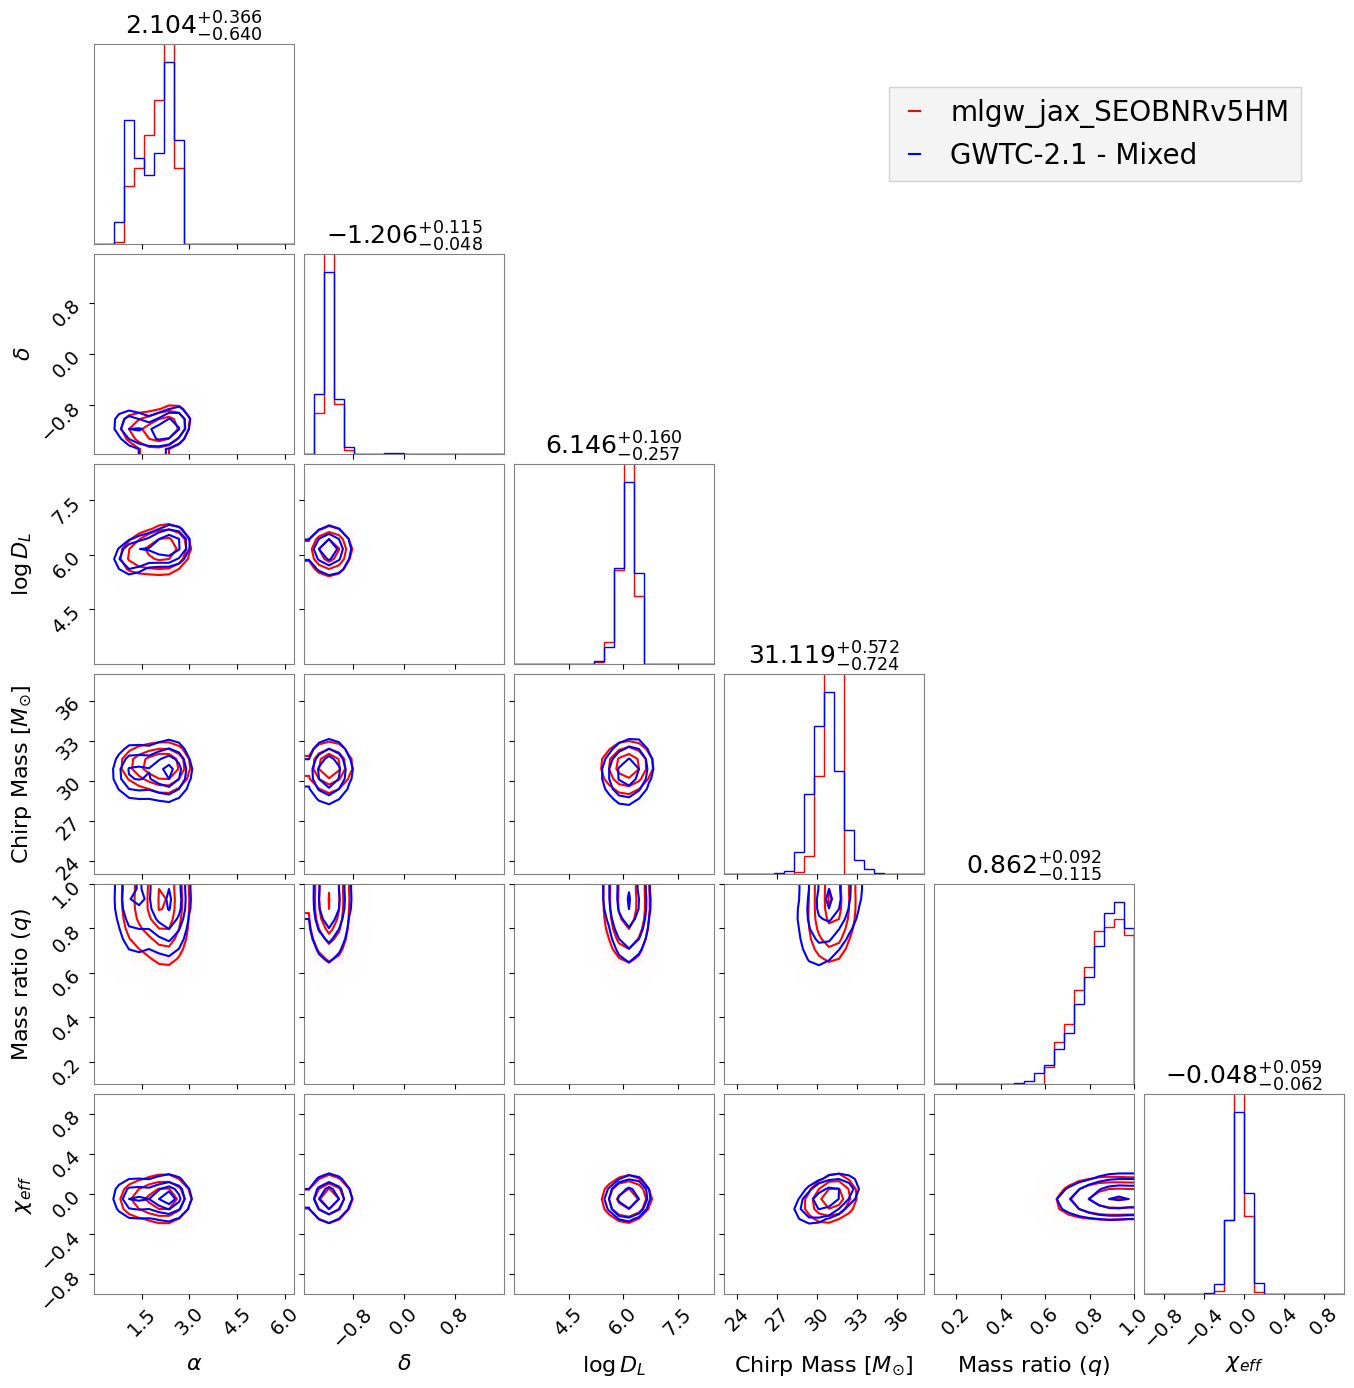

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from pesummary.io import read

# Reload the data into a different variable name because 'data' was overwritten by a numpy array earlier
filename = 'IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo (3).h5'
pe_data = read(filename, disable_prior=True)

# 1. Extract C01:Mixed data from GWTC-2.1
samples_mixed = pe_data.samples_dict['C01:Mixed']

# Extracting and converting relevant parameters
mixed_mc = np.array(samples_mixed['chirp_mass'])
mixed_q = np.array(samples_mixed['mass_ratio'])
mixed_ra = np.mod(np.array(samples_mixed['ra']), 2*np.pi)

# Handle declination/zenith correctly
if 'zenith' in samples_mixed.keys():
    mixed_dec = np.pi/2 - np.array(samples_mixed['zenith'])
else:
    mixed_dec = np.array(samples_mixed['dec'])

mixed_logdl = np.log(np.array(samples_mixed['luminosity_distance']))
mixed_chi_eff = np.array(samples_mixed['chi_eff'])

# Stack the data
mixed_data = np.column_stack([mixed_ra, mixed_dec, mixed_logdl, mixed_mc, mixed_q, mixed_chi_eff])

# 2. Extract MLGW-JAX SEOBNRv5HM data
v5_ra = np.array(result.posterior_samples['ra'])
v5_dec = np.array(result.posterior_samples['dec'])
v5_logdl = np.log(np.array(result.posterior_samples['distance']))
v5_mc = np.array(result.posterior_samples['mc'])
v5_q = np.array(result.posterior_samples['q'])
v5_chi_1 = np.array(result.posterior_samples['chi_1'])
v5_chi_2 = np.array(result.posterior_samples['chi_2'])

# Calculate chi_eff: (m1*chi_1 + m2*chi_2)/(m1+m2) = (q*chi_1 + chi_2)/(1+q) where q = m2/m1 <= 1
v5_chi_eff = (v5_q * v5_chi_1 + v5_chi_2) / (1.0 + v5_q)

# Stack the MLGW-JAX data (v5_q is already m2/m1 <= 1, no need to invert)
v5_data = np.column_stack([v5_ra, v5_dec, v5_logdl, v5_mc, v5_q, v5_chi_eff])

# 3. Define labels and standardized ranges
labels_comp = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'Chirp Mass $[M_{\odot}]$', r'Mass ratio ($q$)', r'$\chi_{eff}$']
ranges_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (3.0, 8.5),          # logDL
    (23.0, 38.0),        # Mc
    (0.1, 1.0),          # q
    (-1, 1)              # chi_eff
]

# Set desired font sizes
LABEL_FONT = 16
TITLE_FONT = 18
TICK_FONT = 14
LEGEND_FONT = 20

# 4. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Red) - Base layer
fig = corner.corner(
    v5_data[-6000:],
    labels=labels_comp,
    range=ranges_comp,
    smooth=1,
    color='red',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': LABEL_FONT},
    title_kwargs={'fontsize': TITLE_FONT},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 Mixed (Blue) - Overlay
corner.corner(
    mixed_data,
    fig=fig,
    range=ranges_comp,
    smooth=0.9,
    color='blue',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# Clean up titles to only show numbers and increase tick font sizes
ndim = len(labels_comp)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    # Extract and modify title on the diagonal
    ax_diag = axes[i, i]
    title = ax_diag.get_title()
    if "=" in title:
        ax_diag.set_title(title.split("=")[-1].strip(), fontsize=TITLE_FONT)

    # Update tick labels size for all axes
    for j in range(ndim):
        axes[i, j].tick_params(axis='both', which='major', labelsize=TICK_FONT)

# 5. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='red', label='mlgw_jax_SEOBNRv5HM')
proxy_mixed = mlines.Line2D([], [], color='blue', label='GWTC-2.1 - Mixed')

fig.legend(handles=[proxy_v5, proxy_mixed], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=LEGEND_FONT, frameon=True, facecolor='#f4f4f4', edgecolor='lightgrey', framealpha=1.0)

# Remove grid lines
for ax in fig.axes:
    ax.grid(False)

plt.savefig('corner_fig_no_incl.png')
plt.show()

2026-07-21  12:49:37 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


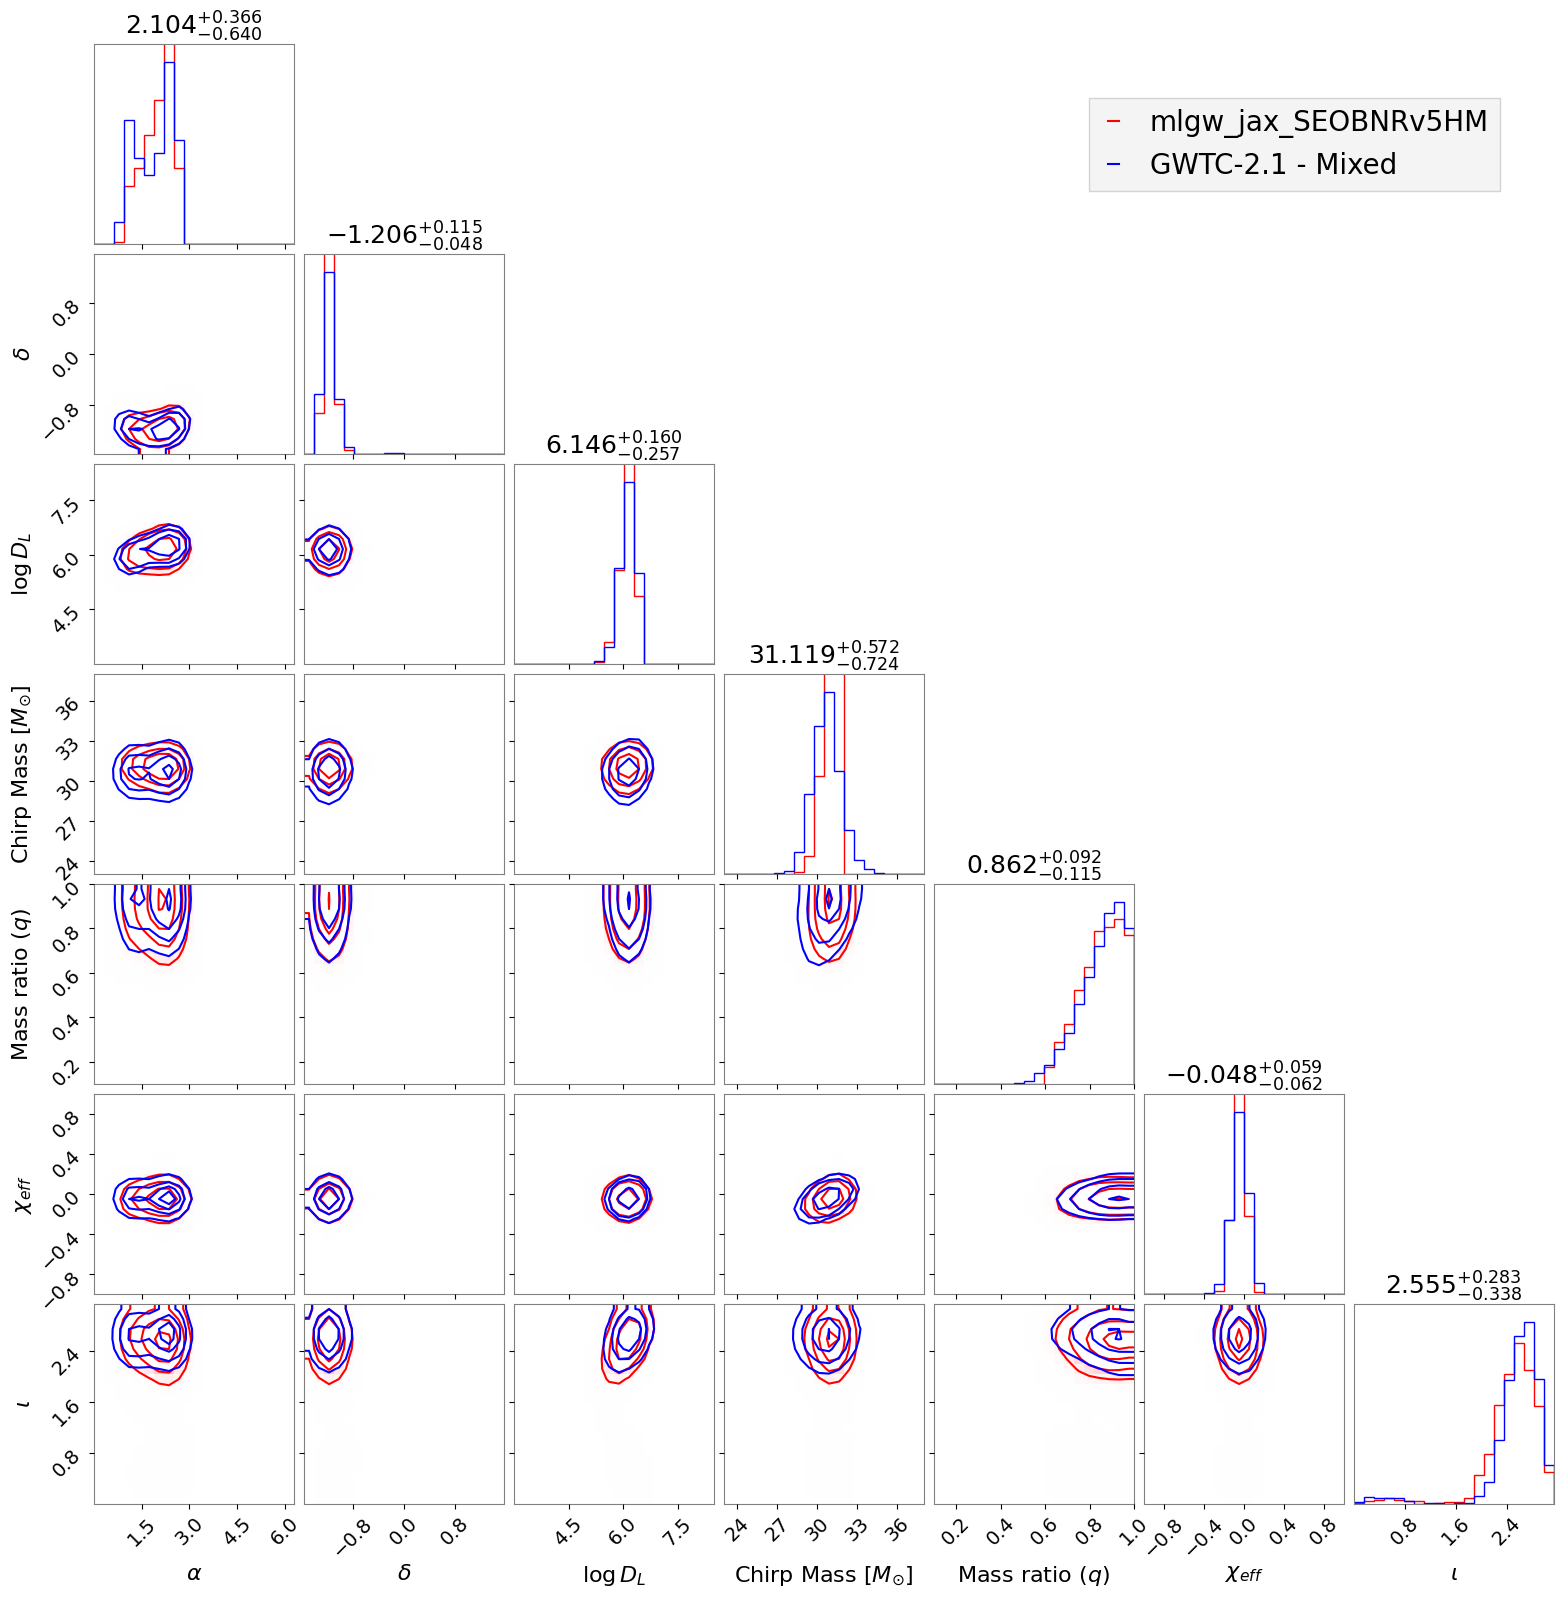

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
from pesummary.io import read

# Reload the data into a different variable name because 'data' was overwritten by a numpy array earlier
filename = 'IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo (3).h5'
pe_data = read(filename, disable_prior=True)

# 1. Extract C01:Mixed data from GWTC-2.1
samples_mixed = pe_data.samples_dict['C01:Mixed']

# Extracting and converting relevant parameters
mixed_mc = np.array(samples_mixed['chirp_mass'])
mixed_q = np.array(samples_mixed['mass_ratio'])
mixed_ra = np.mod(np.array(samples_mixed['ra']), 2*np.pi)

# Handle declination/zenith correctly
if 'zenith' in samples_mixed.keys():
    mixed_dec = np.pi/2 - np.array(samples_mixed['zenith'])
else:
    mixed_dec = np.array(samples_mixed['dec'])

mixed_logdl = np.log(np.array(samples_mixed['luminosity_distance']))
mixed_chi_eff = np.array(samples_mixed['chi_eff'])
mixed_inclination = np.array(samples_mixed['iota']) if 'iota' in samples_mixed.keys() else np.array(samples_mixed['theta_jn'])

# Stack the data
mixed_data = np.column_stack([mixed_ra, mixed_dec, mixed_logdl, mixed_mc, mixed_q, mixed_chi_eff, mixed_inclination])

# 2. Extract MLGW-JAX SEOBNRv5HM data
v5_ra = np.array(result.posterior_samples['ra'])
v5_dec = np.array(result.posterior_samples['dec'])
v5_logdl = np.log(np.array(result.posterior_samples['distance']))
v5_mc = np.array(result.posterior_samples['mc'])
v5_q = np.array(result.posterior_samples['q'])
v5_chi_1 = np.array(result.posterior_samples['chi_1'])
v5_chi_2 = np.array(result.posterior_samples['chi_2'])
v5_inclination = np.array(result.posterior_samples['inclination'])

# Calculate chi_eff: (m1*chi_1 + m2*chi_2)/(m1+m2) = (q*chi_1 + chi_2)/(1+q) where q = m2/m1 <= 1
v5_chi_eff = (v5_q * v5_chi_1 + v5_chi_2) / (1.0 + v5_q)

# Stack the MLGW-JAX data (v5_q is already m2/m1 <= 1, no need to invert)
v5_data = np.column_stack([v5_ra, v5_dec, v5_logdl, v5_mc, v5_q, v5_chi_eff, v5_inclination])

# 3. Define labels and standardized ranges
labels_comp = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'Chirp Mass $[M_{\odot}]$', r'Mass ratio ($q$)', r'$\chi_{eff}$', r'$\iota$']
ranges_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (3.0, 8.5),          # logDL
    (23.0, 38.0),        # Mc
    (0.1, 1.0),          # q
    (-1, 1),             # chi_eff
    (0, np.pi)           # inclination
]

# Set desired font sizes
LABEL_FONT = 16
TITLE_FONT = 18
TICK_FONT = 14
LEGEND_FONT = 20

# 4. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Red) - Base layer
fig = corner.corner(
    v5_data[-6000:],
    labels=labels_comp,
    range=ranges_comp,
    smooth=1,
    color='red',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': LABEL_FONT},
    title_kwargs={'fontsize': TITLE_FONT},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 Mixed (Blue) - Overlay
corner.corner(
    mixed_data,
    fig=fig,
    range=ranges_comp,
    smooth=0.9,
    color='blue',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# Clean up titles to only show numbers and increase tick font sizes
ndim = len(labels_comp)
axes = np.array(fig.axes).reshape((ndim, ndim))
for i in range(ndim):
    # Extract and modify title on the diagonal
    ax_diag = axes[i, i]
    title = ax_diag.get_title()
    if "=" in title:
        ax_diag.set_title(title.split("=")[-1].strip(), fontsize=TITLE_FONT)

    # Update tick labels size for all axes
    for j in range(ndim):
        axes[i, j].tick_params(axis='both', which='major', labelsize=TICK_FONT)

# 5. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='red', label='mlgw_jax_SEOBNRv5HM')
proxy_mixed = mlines.Line2D([], [], color='blue', label='GWTC-2.1 - Mixed')

fig.legend(handles=[proxy_v5, proxy_mixed], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=LEGEND_FONT, frameon=True, facecolor='#f4f4f4', edgecolor='lightgrey', framealpha=1.0)

# Remove grid lines
for ax in fig.axes:
    ax.grid(False)

plt.savefig('corner_fig_with_incl.png')
plt.show()

In [ ]:
import pandas as pd
from google.colab import files

# Convert the posterior samples dictionary to a pandas DataFrame
df_samples = pd.DataFrame(result.posterior_samples)

# Save the DataFrame to a text file (tab-separated)
filename = 'posterior_samples_mlgw_bbh.txt'
df_samples.to_csv(filename, sep='\t', index=False)
print(f'Saved posterior samples to {filename}')

# Download the file to your local machine
files.download(filename)


Saved posterior samples to posterior_samples_mlgw_bbh.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>